In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv('email.csv')

In [3]:
df.sample(5)

,text,spam
4701,Subject: california power 1 / 19 / 00 executi...,0
2942,"Subject: it resources guys , in response to t...",0
4127,"Subject: re : rice course thank you , see you...",0
738,Subject: spend too much on your phone bill ? 2...,1
2361,"Subject: hello hi vince , how are you . it w...",0


In [4]:
df.shape

(5728, 2)

In [5]:
# 1. Data Cleaning
# 2. EDA
# 3. Text Processing
# 4. Model Building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

### 1. Data Cleaning

In [6]:
df.sample(10)

,text,spam
337,"Subject: also available levitra , cialis , and...",1
4994,Subject: v @ r methodology for metal positions...,0
1896,Subject: amerada hess day rate hedge numbers ...,0
4680,Subject: re : invitation . . . welcome new ana...,0
2950,Subject: re : mid - year 2000 performance eval...,0
5533,Subject: fw : opportunities dear sir : i hav...,0
5379,Subject: re : seeking intelligent insight ple...,0
4862,Subject: fyi due to the out of town deliverie...,0
5193,Subject: invitations to presentation only hi ...,0
2534,Subject: ppi index short - term models hi mar...,0


In [7]:
df.rename(columns = { 'spam':'target'},inplace = True)

In [8]:
df.sample(2)

,text,target
1430,"Subject: "" we are one @ enron . com ! "" : fina...",0
3511,"Subject: re : enron , india database sandeep ...",0


In [9]:
# missing values
df.isnull().sum()

text      0
target    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(33)

In [11]:
# remove duplicates
df = df.drop_duplicates(keep = 'first')


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.shape

(5695, 2)

### 2. EDA

In [14]:
df.head()

,text,target
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [15]:
df['target'].value_counts()

target
0    4327
1    1368
Name: count, dtype: int64

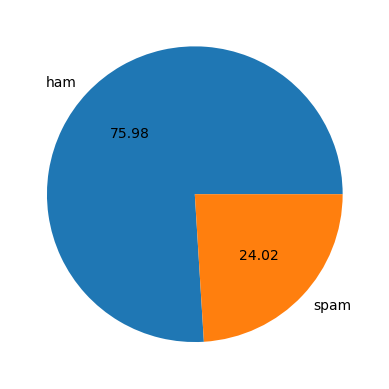

In [16]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts() , labels = ['ham' , 'spam'], autopct = "%0.2f")
plt.show()

In [17]:
# Data is imbalanced


In [18]:
import nltk

In [19]:
!pip install nltk

In [20]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
df["num_characters"] = df['text'].apply(len)

In [23]:
df.head()

,text,target,num_characters
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [24]:
df.head()

,text,target,num_characters
0,Subject: naturally irresistible your corporate...,1,1484
1,Subject: the stock trading gunslinger fanny i...,1,598
2,Subject: unbelievable new homes made easy im ...,1,448
3,Subject: 4 color printing special request add...,1,500
4,"Subject: do not have money , get software cds ...",1,235


In [25]:
df['num_of_words'] = df['text'].apply(lambda x: len( nltk.word_tokenize(x)))

In [26]:
df.head()

,text,target,num_characters,num_of_words
0,Subject: naturally irresistible your corporate...,1,1484,325
1,Subject: the stock trading gunslinger fanny i...,1,598,90
2,Subject: unbelievable new homes made easy im ...,1,448,88
3,Subject: 4 color printing special request add...,1,500,99
4,"Subject: do not have money , get software cds ...",1,235,53


In [27]:
df['num_of_sentences'] = df['text'].apply(lambda x: len( nltk.sent_tokenize(x)))

In [28]:
df.head()

,text,target,num_characters,num_of_words,num_of_sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [29]:
df[['num_characters','num_of_words', 'num_of_sentences']].describe()

,num_characters,num_of_words,num_of_sentences
count,5695.000000,5695.000000,5695.000000
mean,1558.067076,328.214047,19.462511
std,2047.078711,419.654234,35.981993
min,13.000000,3.000000,1.000000
25%,508.500000,102.000000,7.000000
50%,979.000000,211.000000,12.000000
75%,1893.000000,403.000000,22.000000
max,43952.000000,8479.000000,1565.000000


In [30]:
#ham messages
df[df['target'] == 0][['num_characters' ,'num_of_words' , 'num_of_sentences']].describe()

,num_characters,num_of_words,num_of_sentences
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [31]:
# spam messages
df[df['target'] == 1][['num_characters' ,'num_of_words' , 'num_of_sentences']].describe()

,num_characters,num_of_words,num_of_sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


In [32]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

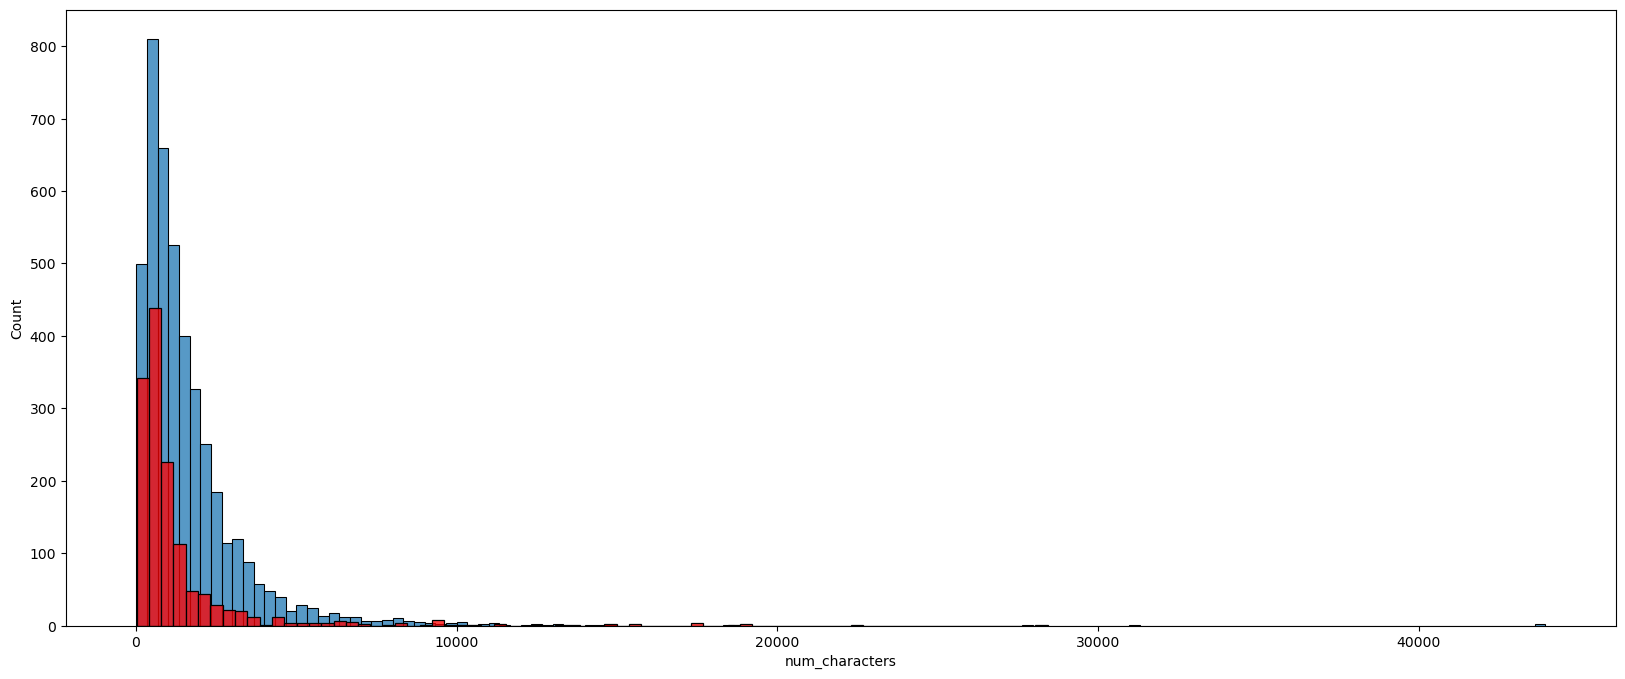

In [33]:
plt.figure(figsize = (20,8))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target']==1 ]['num_characters'],color ='red')

<Axes: xlabel='num_of_words', ylabel='Count'>

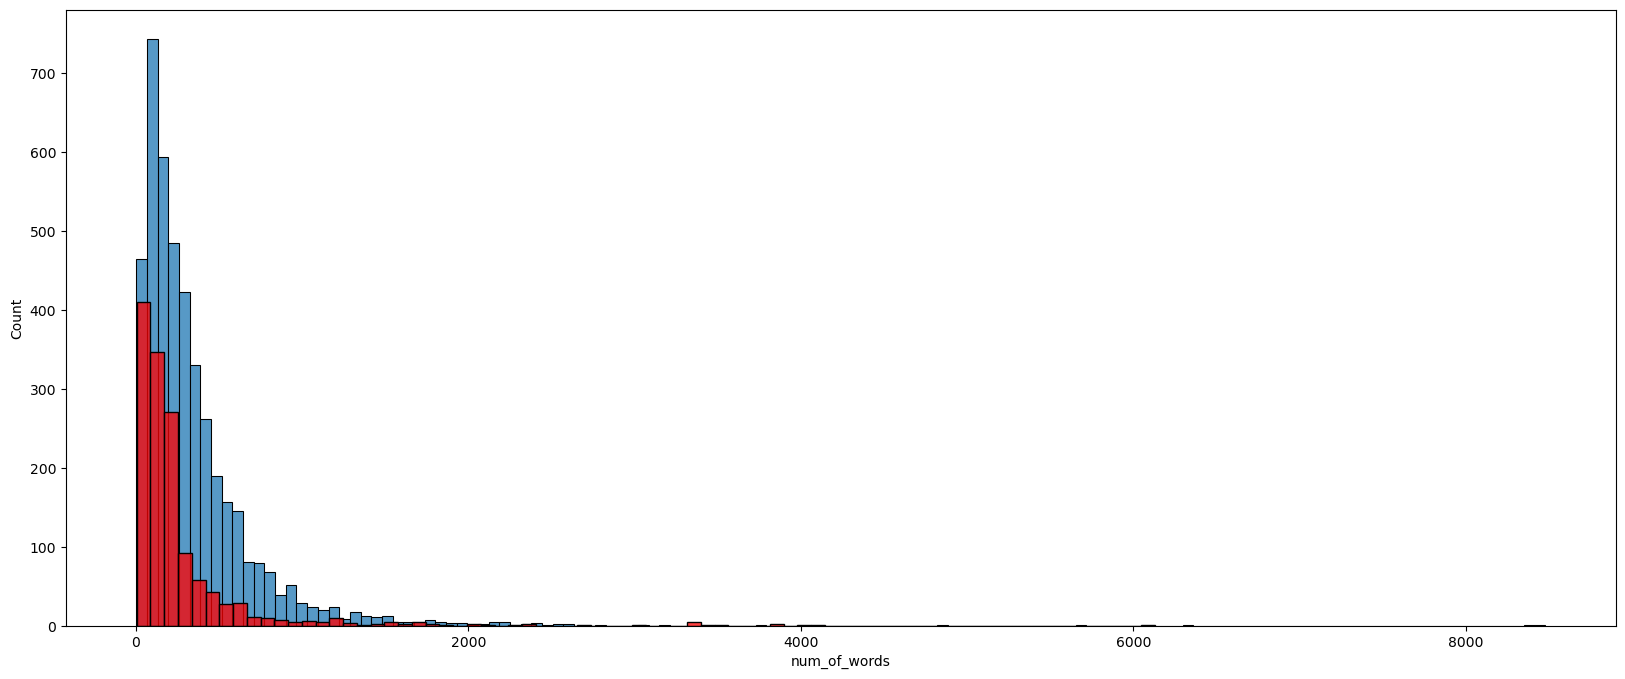

In [34]:
plt.figure(figsize = (20,8))
sns.histplot(df[df['target'] == 0]['num_of_words'])
sns.histplot(df[df['target']==1 ]['num_of_words'],color ='red')

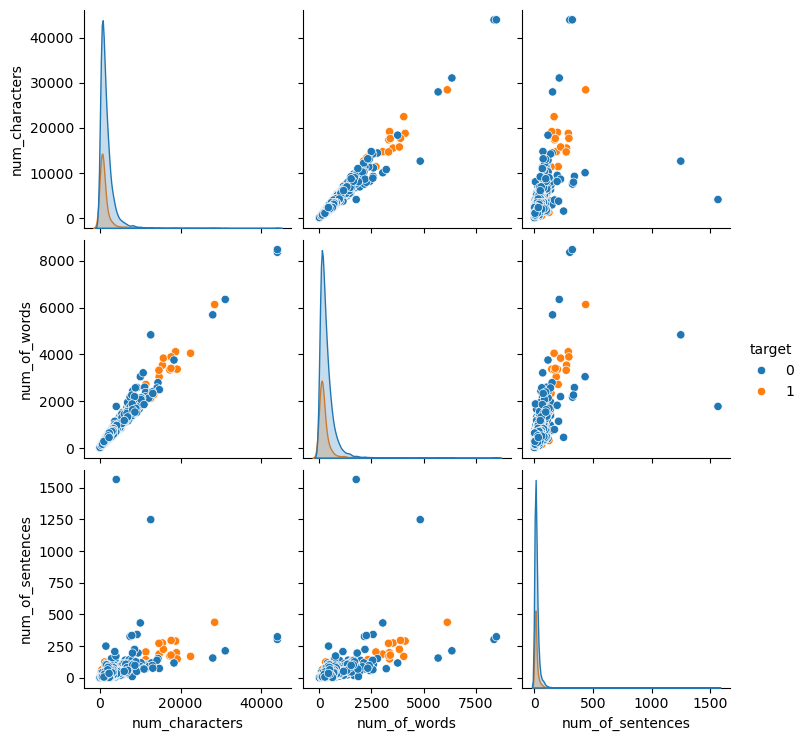

In [35]:
sns.pairplot(df,hue= 'target')

### 3. DATA PREPROCESSING
(It returns only meaningfull words)
1) Lower Case
    2) Tokenization
    3) Removing special characters
    4) removing stop words and punctuation
    5) stemming

In [36]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [38]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [39]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [40]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))   # store once



In [41]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [42]:
transform_text("Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  marketing break - through shouldn ' t make gaps in your budget . 100 % satisfaction  guaranteed : we provide unlimited amount of changes with no extra fees for you to  be surethat you will love the result of this collaboration . have a look at our  portfolio _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ not interested . . . _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _")

'subject natur irresist corpor ident lt realli hard recollect compani market full suqgest inform isoverwhelminq good catchi logo stylish statloneri outstand websit make task much easier promis havinq order iogo compani automaticaili becom world ieader isguit ciear without good product effect busi organ practic aim hotat nowaday market promis market effort becom much effect list clear benefit creativ hand made origin logo special done reflect distinct compani imag conveni logo stationeri provid format easi use content manag system letsyou chang websit content even structur prompt see logo draft within three busi day afford market break make gap budget 100 satisfact guarante provid unlimit amount chang extra fee surethat love result collabor look portfolio interest'

In [43]:
df['text'][0]

"Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  ma

In [44]:
len(df)

5695

In [45]:
transform_text(df.loc[0, 'text'])

'subject natur irresist corpor ident lt realli hard recollect compani market full suqgest inform isoverwhelminq good catchi logo stylish statloneri outstand websit make task much easier promis havinq order iogo compani automaticaili becom world ieader isguit ciear without good product effect busi organ practic aim hotat nowaday market promis market effort becom much effect list clear benefit creativ hand made origin logo special done reflect distinct compani imag conveni logo stationeri provid format easi use content manag system letsyou chang websit content even structur prompt see logo draft within three busi day afford market break make gap budget 100 satisfact guarante provid unlimit amount chang extra fee surethat love result collabor look portfolio interest'

In [46]:
df.head(100)['text'].apply(transform_text)

0     subject natur irresist corpor ident lt realli ...
1     subject stock trade gunsling fanni merril muzo...
2     subject unbeliev new home made easi im want sh...
3     subject 4 color print special request addit in...
4     subject money get softwar cd softwar compat gr...
                            ...                        
95    subject v shoop hello welcom medzonli cloaca n...
96    subject need 15 minut prepar night love gener ...
97    subject requir attorney use system clean recor...
98    subject high qualiti afford logo corpor imag s...
99    subject save money buy get thing tri ciall yet...
Name: text, Length: 100, dtype: object

In [47]:
df['transformed_text'] = df['text'].apply(transform_text)

In [48]:
df.head()

,text,target,num_characters,num_of_words,num_of_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [49]:
df['transformed_text'] = df['transformed_text'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)

In [50]:
df['transformed_text'] = (
    df['transformed_text']
    .str.replace(r'\bsubject\b', '', case=False, regex=True)
)

In [51]:
df['transformed_text'] = (
    df['transformed_text']
    .str.replace(r'^\s*:\s*', '', regex=True)
)

In [52]:
df.head(10)

,text,target,num_characters,num_of_words,num_of_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,natur irresist corpor ident lt realli hard re...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,stock trade gunsling fanni merril muzo colza ...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,unbeliev new home made easi im want show home...
3,Subject: 4 color printing special request add...,1,500,99,5,4 color print special request addit inform cl...
4,"Subject: do not have money , get software cds ...",1,235,53,9,money get softwar cd softwar compat great gro...
5,"Subject: great nnews hello , welcome to medzo...",1,478,85,3,great nnew hello welcom medzonlin sh groundse...
6,Subject: here ' s a hot play in motion homela...,1,9340,1704,72,hot play motion homeland secur invest terror ...
7,Subject: save your money buy getting this thin...,1,446,97,9,save money buy get thing tri ciall yet even i...
8,Subject: undeliverable : home based business f...,1,507,122,3,undeliver home base busi grownup messag home...
9,Subject: save your money buy getting this thin...,1,446,97,9,save money buy get thing tri ciall yet even i...


In [53]:
!pip install wordcloud

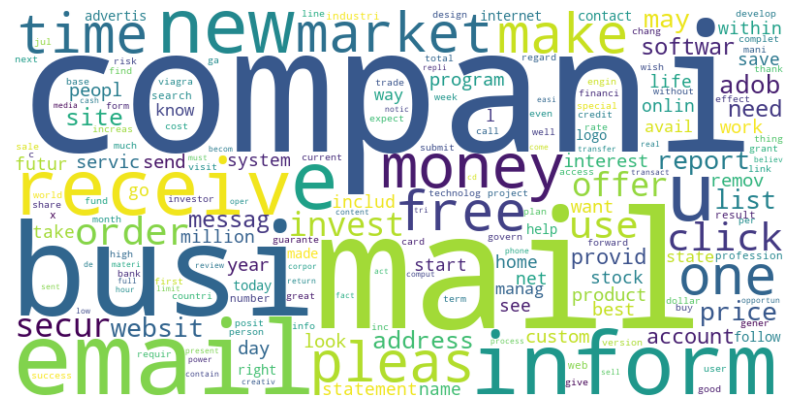

In [54]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
spam_text = df[df['target'] == 1]['transformed_text'].str.cat(sep=' ')

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False,
    prefer_horizontal=1.0
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(10, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

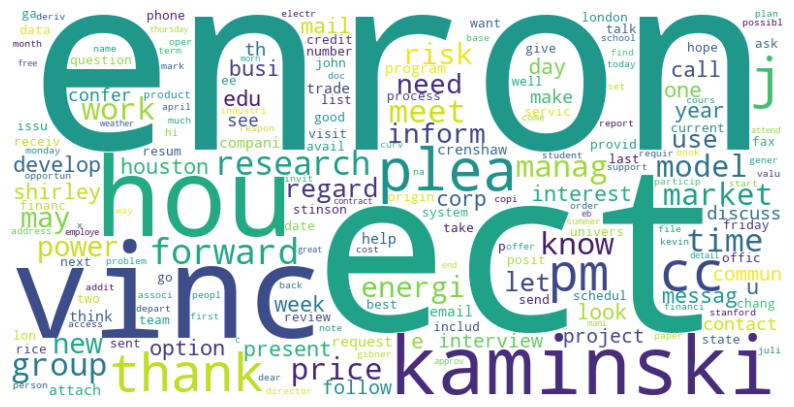

In [55]:
spam_text = df[df['target'] == 0]['transformed_text'].str.cat(sep=' ')

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    collocations=False,
    prefer_horizontal=1.0
)

spam_wc = wc.generate(spam_text)

plt.figure(figsize=(10, 6))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

In [56]:
df.head()

,text,target,num_characters,num_of_words,num_of_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,natur irresist corpor ident lt realli hard re...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,stock trade gunsling fanni merril muzo colza ...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,unbeliev new home made easi im want show home...
3,Subject: 4 color printing special request add...,1,500,99,5,4 color print special request addit inform cl...
4,"Subject: do not have money , get software cds ...",1,235,53,9,money get softwar cd softwar compat great gro...


In [57]:
spam_corpus =[]
for msg in df[df['target']==1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [58]:
len(spam_corpus)

173053

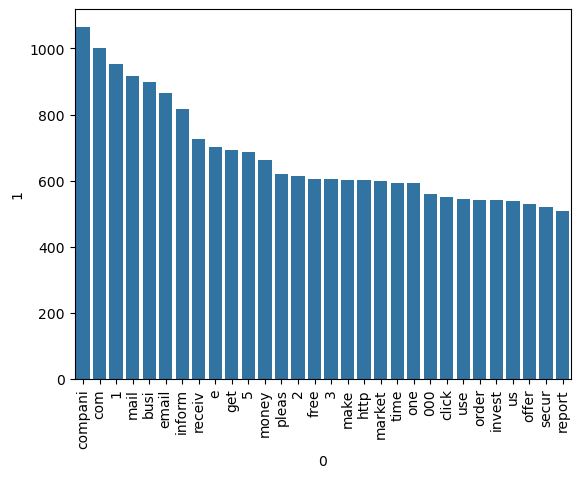

In [59]:
import seaborn as sns
from collections import Counter

top_30_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=top_30_spam[0], y=top_30_spam[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [60]:
ham_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [61]:
len(ham_corpus)


694426

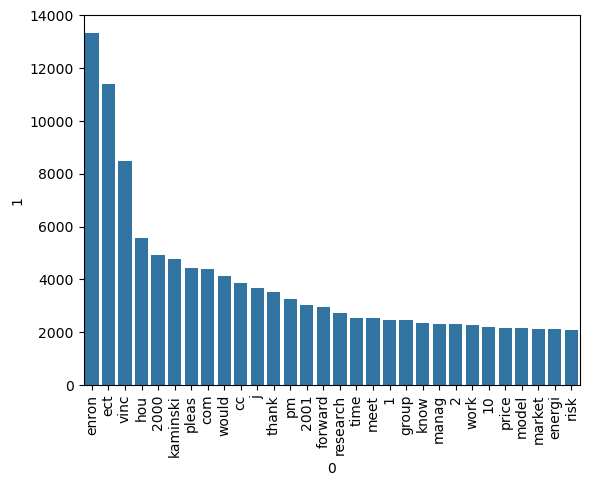

In [62]:
import seaborn as sns
from collections import Counter

top_30_spam = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=top_30_spam[0], y=top_30_spam[1])
plt.xticks(rotation = 'vertical')
plt.show()

4. Model Building

In [102]:
from sklearn.feature_extraction.text import CountVectorizer ,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(
     max_features=3000,
    stop_words='english'
)

In [178]:
X = tfidf.fit_transform(df['transformed_text'])


In [179]:
X.shape

(5695, 3000)

In [180]:
y = df['target'].values

In [181]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(5695,))

In [182]:
from sklearn.model_selection import train_test_split

In [183]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2)

In [184]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB , BernoulliNB
from sklearn.metrics import accuracy_score , confusion_matrix ,precision_score

In [186]:
mnb = MultinomialNB()
bnb = BernoulliNB()


In [188]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test , y_pred2))
print(confusion_matrix(y_test , y_pred2))
print(precision_score(y_test , y_pred2))

0.9859525899912204
[[870   9]
 [  7 253]]
0.9656488549618321


In [189]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test , y_pred3))

0.9438103599648815
[[815  64]
 [  0 260]]
0.8024691358024691


In [190]:
# we chose tfidf -- > mnb


In [191]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier



In [192]:
svc = SVC(kernel = 'sigmoid' , gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear' , penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50 , random_state = 2)
abc = AdaBoostClassifier(n_estimators =50, random_state =2)
bc = BaggingClassifier(n_estimators = 50, random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50, random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50, random_state = 2)
xgb = XGBClassifier(n_estimators = 50, random_state = 2)

In [193]:
clfs = {
    'SVC' :svc,
    'KN' : knc,
    'NB' : mnb,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'AdaBoost' : abc,
    'Bgc' : bc,
    'ETC' : etc,
    'GBDT' : gbdt,
    'xgb' : xgb
}

In [194]:
def train_Classifier(clf , X_train ,y_train, X_test , y_test):
    clf.fit(X_train , y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test , y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy , precision

In [195]:
train_Classifier(svc , X_train , y_train,X_test,y_test)


(0.9894644424934153, 0.984375)

In [196]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_Classifier( clf,X_train , y_train , X_test,y_test)

    print("For" ,name)
    print("Accuracy - " , current_accuracy)
    print("Precision - " , current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy -  0.9894644424934153
Precision -  0.984375
For KN
Accuracy -  0.9780509218612818
Precision -  0.9536679536679536
For NB
Accuracy -  0.9859525899912204
Precision -  0.9656488549618321
For DT
Accuracy -  0.9034240561896401
Precision -  0.7180232558139535
For LR
Accuracy -  0.9754170324846356
Precision -  0.9496124031007752
For RF
Accuracy -  0.9868305531167691
Precision -  0.972972972972973
For AdaBoost
Accuracy -  0.9438103599648815
Precision -  0.8141025641025641
For Bgc
Accuracy -  0.9701492537313433
Precision -  0.9094202898550725
For ETC
Accuracy -  0.9920983318700615
Precision -  0.9883268482490273
For GBDT
Accuracy -  0.9675153643546971
Precision -  0.933852140077821
For xgb
Accuracy -  0.9841966637401229
Precision -  0.9384057971014492


In [197]:
performance_df = pd.DataFrame({'Algorithm' : clfs.keys() , 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Accuracy' , ascending =False)

In [198]:
performance_df

,Algorithm,Accuracy,Precision
8,ETC,0.992098,0.988327
0,SVC,0.989464,0.984375
5,RF,0.986831,0.972973
2,NB,0.985953,0.965649
10,xgb,0.984197,0.938406
1,KN,0.978051,0.953668
4,LR,0.975417,0.949612
7,Bgc,0.970149,0.909420
9,GBDT,0.967515,0.933852
6,AdaBoost,0.943810,0.814103


In [199]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [200]:
performance_df1

,Algorithm,variable,value
0,ETC,Accuracy,0.992098
1,SVC,Accuracy,0.989464
2,RF,Accuracy,0.986831
3,NB,Accuracy,0.985953
4,xgb,Accuracy,0.984197
5,KN,Accuracy,0.978051
6,LR,Accuracy,0.975417
7,Bgc,Accuracy,0.970149
8,GBDT,Accuracy,0.967515
9,AdaBoost,Accuracy,0.943810


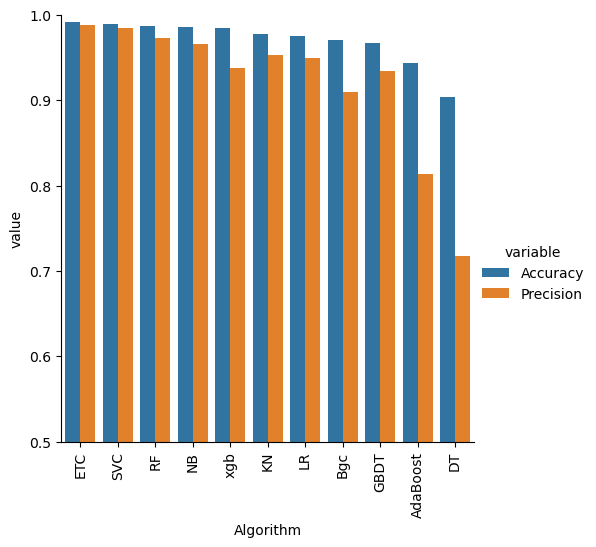

In [201]:
sns.catplot(x = 'Algorithm', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

## model improve

In [202]:
# 1. Change the max_features parameter of TfIdf

In [203]:

temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [204]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [205]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [206]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [207]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [208]:
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,ETC,0.992098,0.988327,0.992098,0.988327,0.992098,0.988327,0.992098,0.988327
1,SVC,0.989464,0.984375,0.989464,0.984375,0.989464,0.984375,0.989464,0.984375
2,RF,0.986831,0.972973,0.986831,0.972973,0.986831,0.972973,0.986831,0.972973
3,NB,0.985953,0.965649,0.985953,0.965649,0.985953,0.965649,0.985953,0.965649
4,xgb,0.984197,0.938406,0.984197,0.938406,0.984197,0.938406,0.984197,0.938406
5,KN,0.978051,0.953668,0.978051,0.953668,0.978051,0.953668,0.978051,0.953668
6,LR,0.975417,0.949612,0.975417,0.949612,0.975417,0.949612,0.975417,0.949612
7,Bgc,0.970149,0.909420,0.970149,0.909420,0.970149,0.909420,0.970149,0.909420
8,GBDT,0.967515,0.933852,0.967515,0.933852,0.967515,0.933852,0.967515,0.933852
9,AdaBoost,0.943810,0.814103,0.943810,0.814103,0.943810,0.814103,0.943810,0.814103


In [209]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [210]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [211]:
voting.fit(X_train,y_train)

,estimators,"[('svm', ...), ('nb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0


In [212]:

y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9920983318700615
Precision 0.9883268482490273


In [213]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [214]:
from sklearn.ensemble import StackingClassifier

In [215]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [216]:
print(X_train.shape)

(4556, 3000)


In [217]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9920983318700615
Precision 0.9845559845559846


In [218]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(clf,open('model.pkl','wb'))